# Clusterización de Clientes – Mall Customers

Este notebook desarrolla un análisis completo de **clusterización jerárquica**, comparación con **K-Means** y recomendaciones de negocio, utilizando las variables:
- Annual Income (k$)
- Spending Score (1-100)

El análisis es reproducible y sigue buenas prácticas de ciencia de datos.

## 1. Carga de librerías y datos

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:

df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Selección de variables y escalamiento

In [4]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Clusterización Jerárquica

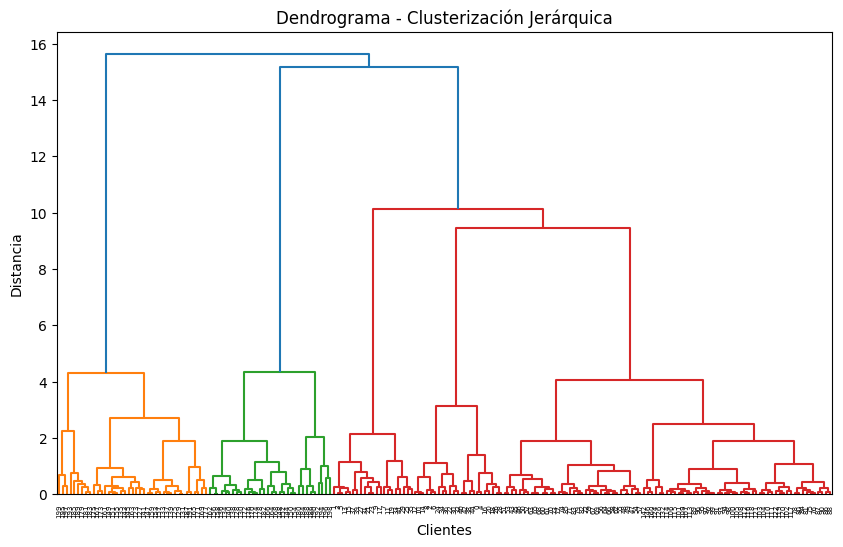

In [5]:

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrograma - Clusterización Jerárquica")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.show()


In [6]:

df['Cluster_H'] = fcluster(Z, t=5, criterion='maxclust')
df.groupby('Cluster_H')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster_H,,
1,86.538462,82.128205
2,89.406250,15.593750
3,25.095238,80.047619
4,26.304348,20.913043
5,55.811765,49.129412


## 4. Visualización de clusters jerárquicos

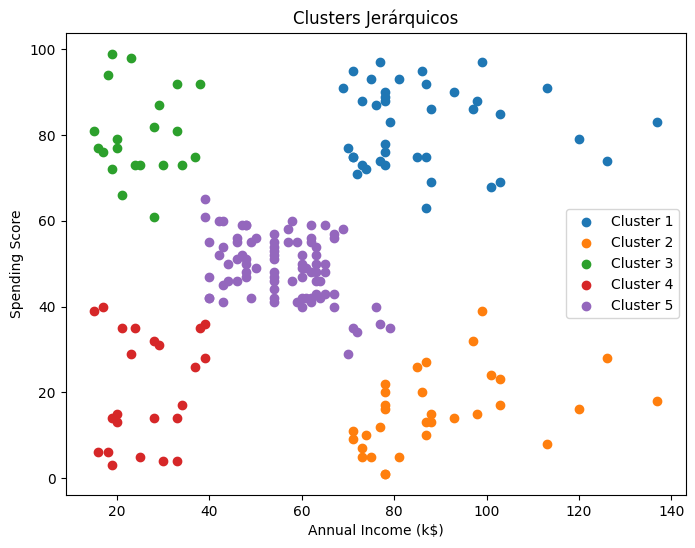

In [7]:

plt.figure(figsize=(8,6))
for c in sorted(df['Cluster_H'].unique()):
    subset = df[df['Cluster_H'] == c]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'], label=f'Cluster {c}')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Clusters Jerárquicos")
plt.legend()
plt.show()


## 5. Comparación con K-Means

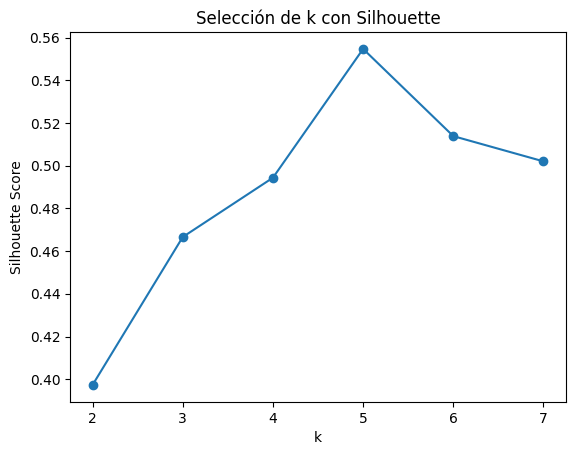

In [8]:

sil_scores = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Selección de k con Silhouette")
plt.show()


In [9]:

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_KM'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster_KM')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster_KM,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## 6. Recomendaciones de negocio por cluster


- **Alto ingreso / Alto gasto**: clientes premium → fidelización, experiencias exclusivas.
- **Alto ingreso / Bajo gasto**: potencial no explotado → campañas personalizadas.
- **Ingreso medio / Gasto medio**: clientes estables → marketing general.
- **Bajo ingreso / Alto gasto**: impulsivos → promociones controladas.
- **Bajo ingreso / Bajo gasto**: bajo valor → mínima inversión.


## 7. Conclusiones


- La clusterización jerárquica identifica claramente **5 segmentos naturales**.
- El dendrograma permite justificar visualmente el número de clusters.
- K-Means confirma una estructura similar.
- Los resultados son accionables desde el punto de vista comercial y estratégico.


revisar grupo 5
tarea buena